# Cheap selection filters on BDD100K

Compare the four stock filters documented in [Phase 1](../docs/experiments/phase1/index.md): accept-all (B-floor), uniform reservoir replay (B1), within-batch semantic deduplication, and high-loss selection (B3).

This is a bounded, exploratory MAE experiment, not a degradation gate or a new P1.2 result. The current P1.2 verdict found no adaptation benefit for the tested TinyViT vehicles. A small randomly initialized MAE makes this notebook runnable without downloading weights; it does not establish the value of continual adaptation.

Each arm gets the same initialization, regime-ordered stream and held-out scene probes. Attributes order the stream and label evaluation only; filters receive no labels. These are attribute blocks over still images, not temporal video order. Replay adds training examples, while admission filters remove them: report training exposure and wall time alongside quality rather than calling this compute-matched.

Use the project's Python environment as the notebook kernel. The notebook also needs pandas, matplotlib and IPython (available in the temporary validation environment via uv run --with pandas --with matplotlib --with ipython).

**P1.3 continuation:** the final sections add a separate warm-start selection/retention protocol. The earlier four-filter comparison remains an engineering pilot. Its figures and outputs must not be interpreted as P1.3 evidence.


In [39]:
import sys
from pathlib import Path

# VS Code can start this notebook inside the package directory.
repo_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "cafl4ds/configs").is_dir()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Open this notebook from within the cafl4ds repository.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [40]:
import random
from datetime import datetime, timezone
from pathlib import Path
from time import perf_counter
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from hydra.utils import instantiate
from IPython.display import display as show
from loguru import logger
from omegaconf import OmegaConf

from cafl4ds.data.regime import RegimeStream
from cafl4ds.data.streams import EvalSet, EvalSets, StreamBatch
from cafl4ds.filters.base import Filter, FilterContext
from cafl4ds.harness import run_stream_arm
from cafl4ds.jsonio import dumps_valid
from cafl4ds.monitor import HealthMonitor

## What question are we asking?

Imagine a camera sending a long sequence of road images. Training on every image may spend work on very similar scenes. A filter decides what reaches the next learning update. We want to see whether it can reduce that work while preserving useful image features.

| Filter | What happens to one incoming batch? | What to watch |
| --- | --- | --- |
| Accept-all | Every incoming image reaches training. | The reference for the cost and quality of the other filters. |
| Reservoir replay | All incoming images are used, plus a random sample of earlier images. The buffer stores at most 256 images with the stock config. | More training presentations may help preserve earlier information, but they cost extra work. |
| Semantic deduplication | The current model embeds the images. A greedy pass removes images whose cosine similarity to a kept image exceeds 0.9. | This only compares images within the current batch. An untrained model can consider different images similar and reject too much. |
| Loss gate | The current MAE scores reconstruction difficulty and keeps the half with the highest loss. | Difficulty is a heuristic, not a guarantee of usefulness. Scoring discarded images also costs time. |

The MAE learns by reconstructing hidden image patches. Scene labels never drive this learning or the filters. Separately, fixed held-out images test whether the learned features help distinguish scenes such as highway and city street.

**Read the figures in order:** check the available driving conditions, inspect how much data reaches training, then compare quality against the work spent. A filter that makes no updates may look stable simply because the model never changes.


## Settings

Change `bdd_root` to the dataset directory containing `images/100k` and `labels`. Set `images_dir` directly if your layout differs. BDD attribute JSON is required in addition to images; `labels_file` accepts a combined JSON file or a directory of per-image JSON records.

The source caches decoded float32 images in RAM. The default cap is deliberate: 2,000 images at 64 pixels require about 94 MiB for image tensors, before stream/evaluation copies. Removing the cap loads the full split. The cap uses the first attribute-valid records, so this pilot is not a representative full-dataset estimate. Expand the data and seeds before drawing conclusions.

CUDA is preferred. The setup checks that a small GPU operation works and falls back to CPU if CUDA is unavailable or fails that check. Set `prefer_cuda = False` to force CPU. An out-of-memory failure during training still stops the run: reduce `batch_size` or `img_size`, or force CPU, then rerun from Settings. This avoids silently mixing CPU and GPU timings in one comparison.


In [41]:
bdd_root = Path(r"D:\AI Proj\bdd100k_images_100k")
bdd_split = "train"
images_dir = bdd_root / "images" / "100k" / bdd_split
labels_file = bdd_root / "labels" / f"bdd100k_labels_images_{bdd_split}.json"

seeds = [13]  # Extend, e.g. [13, 42, 101], for replication.
img_size = 64
batch_size = 32
max_images = 2000
max_train_per_regime = 128
support_per_canary = 8
query_per_canary = 8
min_canary_count = 32
canary_seed = 0
eval_every = 5
prefer_cuda = True  # Set False to force CPU.
device = "cpu"
if prefer_cuda and torch.cuda.is_available():
    try:
        # Check a real allocation and operation, not just driver discovery.
        cuda_probe = torch.ones(8, device="cuda")
        _ = (cuda_probe * cuda_probe).sum().item()
        torch.cuda.synchronize()
        del cuda_probe
        device = "cuda"
    except RuntimeError as exc:
        logger.warning("CUDA startup failed; using CPU: {}", exc)
logger.info("Compute: {}", torch.cuda.get_device_name(0) if device == "cuda" else "CPU")
filter_names = ["accept_all", "reservoir", "dedup", "loss_gate"]

method_cfg = OmegaConf.create(
    {
        "_target_": "cafl4ds.ssl.factory.build_mae",
        "encoder": {
            "_target_": "cafl4ds.models.vit.TinyViTEncoder",
            "img_size": img_size,
            "patch_size": 8,
            "embed_dim": 64,
            "depth": 2,
            "num_heads": 4,
            "mlp_ratio": 2.0,
        },
        "decoder_dim": 32,
        "decoder_depth": 1,
        "decoder_heads": 4,
        "mask_ratio": 0.75,
    }
)
optimizer_cfg = OmegaConf.create({"_target_": "torch.optim.AdamW", "lr": 1e-4, "weight_decay": 1e-4})
stream_cfg = OmegaConf.create(
    {
        "_target_": "cafl4ds.data.regime.RegimeStream",
        "batch_size": batch_size,
        "support_per_canary": support_per_canary,
        "query_per_canary": query_per_canary,
        "era_query_per_cell": 0,
        "max_train_per_regime": max_train_per_regime,
        "canary_seed": canary_seed,
    }
)
source_cfg = OmegaConf.create(
    {
        "_target_": "cafl4ds.data.attributes.BDD100KSource",
        "bdd_root": str(bdd_root),
        "split": bdd_split,
        "images_dir": str(images_dir),
        "labels_file": str(labels_file),
        "img_size": img_size,
        "max_images": max_images,
        "min_canary_count": min_canary_count,
    }
)
logger.info("Device: {}; filters: {}", device, filter_names)

2026-09-28 22:01:50.285 | INFO     | __main__:<module>:28 - Compute: NVIDIA GeForce GTX 1660 Ti
2026-09-28 22:01:50.287 | INFO     | __main__:<module>:73 - Device: cuda; filters: ['accept_all', 'reservoir', 'dedup', 'loss_gate']


In [42]:
if not images_dir.is_dir():
    raise FileNotFoundError(f"Set bdd_root/images_dir to your BDD image folder: {images_dir}")
if not labels_file.exists():
    raise FileNotFoundError(f"Set labels_file to the BDD attributes JSON or per-image JSON directory: {labels_file}")
source = instantiate(source_cfg)
preview = instantiate(stream_cfg, source=source, seed=seeds[0])
if len(preview) == 0:
    raise ValueError("No training batches remain; increase max_images or reduce probe reservations.")
logger.info("{} batches; {} regimes; {} scene classes", len(preview), preview.num_eras, len(preview.canary_names))
show(pd.DataFrame([{"era": k, "regime": v} for k, v in preview.era_names.items()]))

2026-09-28 22:01:59.718 | INFO     | cafl4ds.data.attributes:_drop_rare_scenes:455 - BDD100KSource: dropped rare scenes below min_canary_count=32: ['parking lot', 'tunnel']
2026-09-28 22:02:08.796 | INFO     | cafl4ds.data.attributes:_decode:332 - BDD100KSource: loaded 1984 images (train) at 64px over 17 regimes, 3 scenes
2026-09-28 22:02:09.240 | INFO     | __main__:<module>:9 - 38 batches; 17 regimes; 3 scene classes


,era,regime
0,0,daytime·clear
1,1,daytime·partly cloudy
2,2,daytime·overcast
3,3,daytime·rainy
4,4,daytime·snowy
5,5,daytime·foggy
6,6,dawn/dusk·clear
7,7,dawn/dusk·partly cloudy
8,8,dawn/dusk·overcast
9,9,dawn/dusk·rainy


## 1. What does this stream contain?

Each row below is a driving condition, defined by time of day and weather. The bars count actual training arrivals **after** held-out evaluation images and the per-condition cap have been removed. A short bar means less opportunity to learn that condition.

The bottom panel shows their order for the first seed. Long blocks create a changing diet: the model sees one condition for a while, then another. These are grouped still images, not consecutive frames from a drive. Other seeds shuffle within each condition and may change which capped images are used.


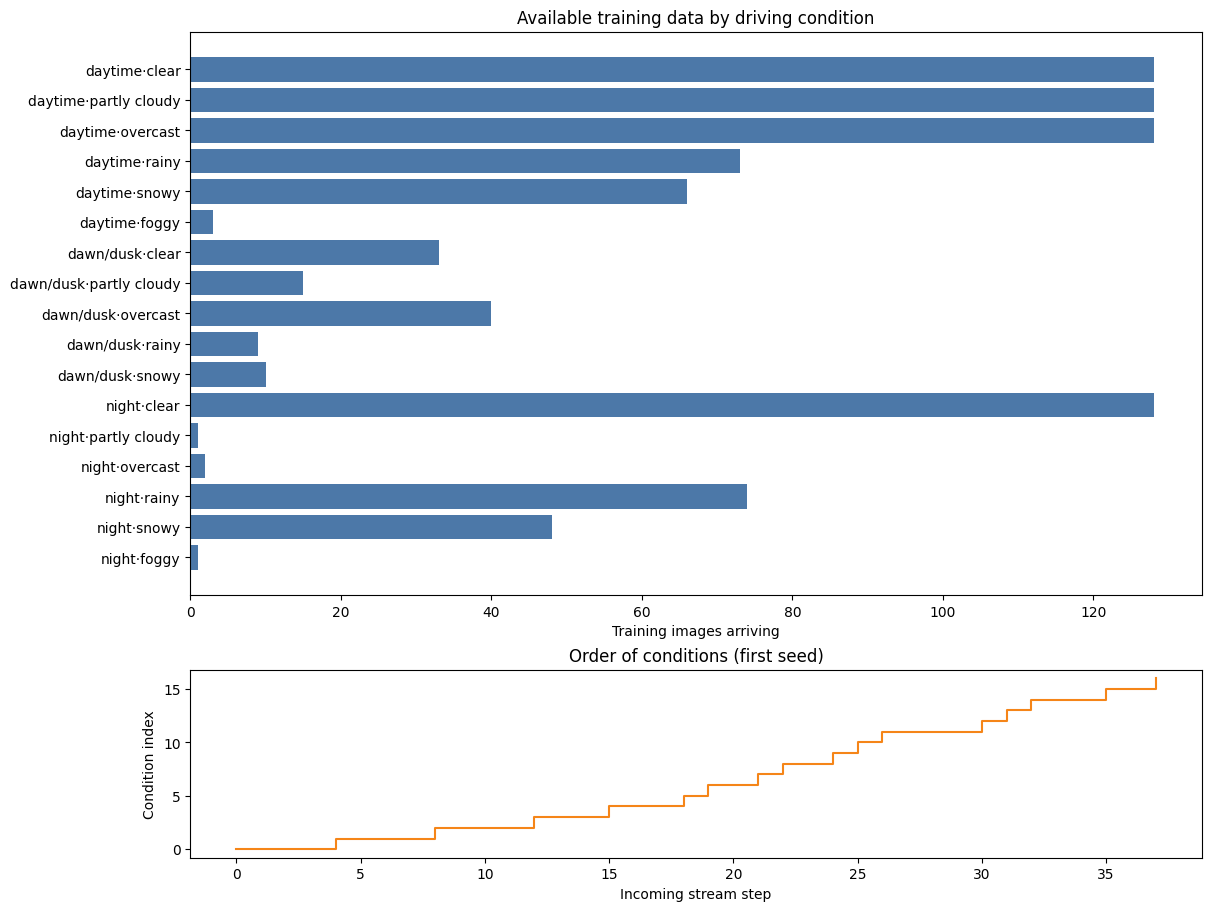

In [43]:
stream_rows = [{"step": batch.step, "era": batch.era, "images": len(batch.images)} for batch in preview]
stream_df = pd.DataFrame(stream_rows)
era_counts = stream_df.groupby("era")["images"].sum()
fig, axes = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={"height_ratios": [3, 1]}, constrained_layout=True)
axes[0].barh([preview.era_names[int(era)] for era in era_counts.index], era_counts.values, color="#4c78a8")
axes[0].invert_yaxis()
axes[0].set(xlabel="Training images arriving", title="Available training data by driving condition")
axes[1].step(stream_df["step"], stream_df["era"], where="post", color="#f58518")
axes[1].set(xlabel="Incoming stream step", ylabel="Condition index", title="Order of conditions (first seed)")
plt.show()
# Save this figure after the run creates its output folder.
stream_figure = fig

## Run the comparison

Filters are instantiated from the repository's Hydra configs, including their stock thresholds and buffer settings. Reservoir replay is composed through `CompositeSelector`, as required by the loop interface.

Counts distinguish stream arrivals from optimizer image presentations (including replay). The loop skips selected batches smaller than two; these are counted separately. A frozen initial reading supplies the B5 reference and anchors drift before the first update. Wall time includes filtering, training, monitoring and logging, but excludes dataset loading. Different filters consume different augmentation/masking random draws, even with the same seed.

Per-batch selection records are saved as `selection.csv` and individual arm files. They contain counts only, not labels or retained images. Training exposure counts repeat presentations of replayed images; it is not a count of unique images.

The dashboard below answers three questions before interpreting any health curves: **Did the filter actually train? Did it improve either probe? How much did it cost?** Bars summarize seeds; individual dots retain the seed-level results. With one seed there is no estimate of run-to-run uncertainty. Runtime includes monitoring and logging, so it is not a pure training-throughput benchmark.


In [44]:
def seed_all(seed: int) -> None:
    """Reset model and augmentation RNGs for a paired arm."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def filter_config(name: str, seed: int) -> dict[str, Any]:
    """Resolve a stock filter config for this seed and batch size."""
    cfg = OmegaConf.create({"batch_size": batch_size, "seed": seed})
    cfg.selection = OmegaConf.load(repo_root / "cafl4ds/configs/filter" / f"{name}.yaml")
    return OmegaConf.to_container(cfg.selection, resolve=True)


class RecordingFilter(Filter):
    """Count optimizer presentations separately from incoming frames."""

    def __init__(self, wrapped: Filter) -> None:
        """Wrap a selector with exposure counters."""
        self.wrapped = wrapped
        self.arrivals = 0
        self.train_presentations = 0
        self.skipped_batches = 0
        self.batch_records: list[dict[str, int]] = []

    def select(self, batch: StreamBatch, ctx: FilterContext) -> torch.Tensor:
        """Select images and count batches eligible for optimization."""
        self.arrivals += len(batch.images)
        selected = self.wrapped.select(batch, ctx)
        if len(selected) < 2:
            self.skipped_batches += 1
        else:
            self.train_presentations += len(selected)
        self.batch_records.append(
            {
                "step": batch.step,
                "era": batch.era,
                "arrivals": len(batch.images),
                "selected": len(selected),
                "trained": len(selected) if len(selected) >= 2 else 0,
                "skipped": int(len(selected) < 2),
            }
        )
        return selected

    def auxiliary_loss(self, images: torch.Tensor, ctx: FilterContext) -> torch.Tensor | None:
        """Delegate optional regularization to the selector."""
        return self.wrapped.auxiliary_loss(images, ctx)


def make_monitor(stream: RegimeStream) -> HealthMonitor:
    """Move held-out probes to the device and build a fresh monitor."""

    def move(part: EvalSet) -> EvalSet:
        return EvalSet(images=part.images.to(device), labels=part.labels.to(device))

    ev = stream.eval_sets
    eval_sets = EvalSets(
        probe_support=move(ev.probe_support),
        probe_query=move(ev.probe_query),
        per_era={k: move(v) for k, v in ev.per_era.items()},
    )
    return instantiate(
        {"_target_": "cafl4ds.monitor.HealthMonitor", "knn_k": 5, "run_alignment": False}, eval_sets=eval_sets
    )


def run_one(name: str, seed: int, output_dir: Path) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    """Run one paired arm and return summary and health records."""
    seed_all(seed)
    stream = instantiate(stream_cfg, source=source, seed=seed)
    method = instantiate(method_cfg).to(device)
    optimizer = instantiate(optimizer_cfg, params=method.parameters())
    selector = RecordingFilter(instantiate(filter_config(name, seed)))
    monitor = make_monitor(stream)
    initial = monitor.measure(method, -1)
    # Reset random draws after the common initial probe measurement.
    seed_all(seed)
    if device == "cuda":
        torch.cuda.synchronize()
    start = perf_counter()
    arm = run_stream_arm(
        name=f"{name}_seed{seed}",
        role="live",
        method=method,
        stream=stream,
        optimizer=optimizer,
        selection_filter=selector,
        monitor=monitor,
        out_dir=output_dir,
        eval_every=eval_every,
        device=device,
    )
    if device == "cuda":
        torch.cuda.synchronize()
    # Skipped updates can leave the loop without a terminal health record.
    terminal = monitor.measure(method, len(stream) - 1) if not arm.diverged else None
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = perf_counter() - start
    final = terminal if terminal is not None else {k: float("nan") for k in initial}
    pd.DataFrame(selector.batch_records).assign(filter=name, seed=seed).to_csv(
        output_dir / f"{name}_seed{seed}_selection.csv", index=False
    )
    summary = {
        "filter": name,
        "seed": seed,
        "diverged": arm.diverged,
        "arrivals": selector.arrivals,
        "train_presentations": selector.train_presentations,
        "presentations_per_arrival": selector.train_presentations / max(1, selector.arrivals),
        "updates": len(arm.loss_records),
        "skipped_batches": selector.skipped_batches,
        "wall_seconds": elapsed,
        "device": device,
    }
    for metric in ["knn_acc", "linear_acc", "rankme", "cosine_drift"]:
        summary[f"initial_{metric}"] = initial[metric]
        summary[f"final_{metric}"] = final[metric]
        summary[f"delta_{metric}"] = final[metric] - initial[metric]
    records = [{"filter": name, "seed": seed, **initial}]
    records.extend({"filter": name, "seed": seed, **r} for r in arm.health)
    if terminal is not None and (not arm.health or arm.health[-1]["step"] != terminal["step"]):
        records.append({"filter": name, "seed": seed, **terminal})
    return summary, records

In [45]:
output_dir = (
    repo_root / "outputs" / "selection-filter-experiment" / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
)
output_dir.mkdir(parents=True, exist_ok=False)
manifest = {
    "source": OmegaConf.to_container(source_cfg, resolve=True),
    "stream": OmegaConf.to_container(stream_cfg, resolve=True),
    "method": OmegaConf.to_container(method_cfg, resolve=True),
    "optimizer": OmegaConf.to_container(optimizer_cfg, resolve=True),
    "filters": {str(s): {n: filter_config(n, s) for n in filter_names} for s in seeds},
    "seeds": seeds,
    "device": device,
    "eval_every": eval_every,
    "torch_version": torch.__version__,
    "purpose": "exploratory cheap-filter comparison",
}
(output_dir / "config.json").write_text(dumps_valid(manifest), encoding="utf-8")
summaries, health_records = [], []
for seed in seeds:
    for name in filter_names:
        logger.info("Running {} with seed {}", name, seed)
        summary, records = run_one(name, seed, output_dir)
        summaries.append(summary)
        health_records.extend(records)
        # Save after every arm, preserving completed results if a later arm fails.
        pd.DataFrame(summaries).to_csv(output_dir / "summary.csv", index=False)
        pd.DataFrame(health_records).to_csv(output_dir / "health.csv", index=False)
summary_df = pd.DataFrame(summaries)
health_df = pd.DataFrame(health_records)
show(summary_df)
logger.info("Saved experiment to {}", output_dir)
selection_df = pd.concat(
    [pd.read_csv(output_dir / f"{name}_seed{seed}_selection.csv") for seed in seeds for name in filter_names],
    ignore_index=True,
)
selection_df.to_csv(output_dir / "selection.csv", index=False)

2026-09-28 22:02:09.472 | INFO     | __main__:<module>:21 - Running accept_all with seed 13
2026-09-28 22:02:09.566 | INFO     | cafl4ds.run_log:log_health:86 - [accept_all_seed13] health step=0.0000 era=0.0000 loss=1.2801 rankme=3.9410 cka_drift=0.0002 cosine_drift=0.0027 knn_acc=0.2917 linear_acc=0.3333
2026-09-28 22:02:09.670 | INFO     | cafl4ds.run_log:log_health:86 - [accept_all_seed13] health step=5.0000 era=1.0000 loss=1.2259 rankme=3.7544 cka_drift=0.0058 cosine_drift=0.0691 knn_acc=0.2917 linear_acc=0.3333
2026-09-28 22:02:09.768 | INFO     | cafl4ds.run_log:log_health:86 - [accept_all_seed13] health step=10.0000 era=2.0000 loss=1.2010 rankme=3.5800 cka_drift=0.0122 cosine_drift=0.1641 knn_acc=0.2500 linear_acc=0.3750
2026-09-28 22:02:09.866 | INFO     | cafl4ds.run_log:log_health:86 - [accept_all_seed13] health step=15.0000 era=4.0000 loss=1.1718 rankme=3.4490 cka_drift=0.0151 cosine_drift=0.2470 knn_acc=0.2500 linear_acc=0.3750
2026-09-28 22:02:09.914 | DEBUG    | cafl4ds.l

,filter,seed,diverged,arrivals,train_presentations,presentations_per_arrival,updates,skipped_batches,wall_seconds,device,...,delta_knn_acc,initial_linear_acc,final_linear_acc,delta_linear_acc,initial_rankme,final_rankme,delta_rankme,initial_cosine_drift,final_cosine_drift,delta_cosine_drift
0,accept_all,13,False,887,884,0.996618,35,3,0.677416,cuda,...,-0.083333,0.375,0.375000,0.000000,3.970032,3.192445,-0.777587,0.0,0.414485,0.414485
1,reservoir,13,False,887,2071,2.334837,38,0,0.730671,cuda,...,-0.083333,0.375,0.291667,-0.083333,3.970032,3.177737,-0.792296,0.0,0.449422,0.449422
2,dedup,13,False,887,18,0.020293,9,29,0.432768,cuda,...,0.000000,0.375,0.291667,-0.083333,3.970032,3.742444,-0.227588,0.0,0.094071,0.094071
3,loss_gate,13,False,887,440,0.496054,33,5,0.662863,cuda,...,-0.041667,0.375,0.250000,-0.125000,3.970032,3.216813,-0.753219,0.0,0.379951,0.379951


2026-09-28 22:02:12.166 | INFO     | __main__:<module>:31 - Saved experiment to c:\Users\muham\Documents\cafl4ds\outputs\selection-filter-experiment\20260928T200209464698Z


### Compare outcomes before interpreting trajectories

**Presentations per arrival:** 1 means one optimizer image presentation per incoming image; replay can exceed 1. **Skipped batches:** selection returned fewer than two images, so the loop did not update. **Runtime relative to accept-all:** below 1 is faster in this measured run. Costs include monitoring, and these short timings are sensitive to warm-up and execution order.

The table includes seed-level accuracy gains against both the frozen start and accept-all. Diverged runs are flagged and excluded from completed-run endpoint plots. The runtime panel is descriptive; it does not establish a throughput advantage without repeated timings.


Query images: 24; one changed prediction = 4.17 percentage points.
Seeds: 1. Dots show individual runs; bars show means, not confidence intervals.


,filter,seed,diverged,updates,skipped_percent,presentations_per_arrival,relative_runtime,vs_frozen_knn_acc_pp,vs_frozen_linear_acc_pp,vs_accept_all_knn_acc_pp,vs_accept_all_linear_acc_pp
0,accept_all,13,False,35,7.895,0.997,1.000,-8.333,0.000,0.000,0.000
1,reservoir,13,False,38,0.000,2.335,1.079,-8.333,-8.333,0.000,-8.333
2,dedup,13,False,9,76.316,0.020,0.639,0.000,-8.333,8.333,-8.333
3,loss_gate,13,False,33,13.158,0.496,0.979,-4.167,-12.500,4.167,-12.500


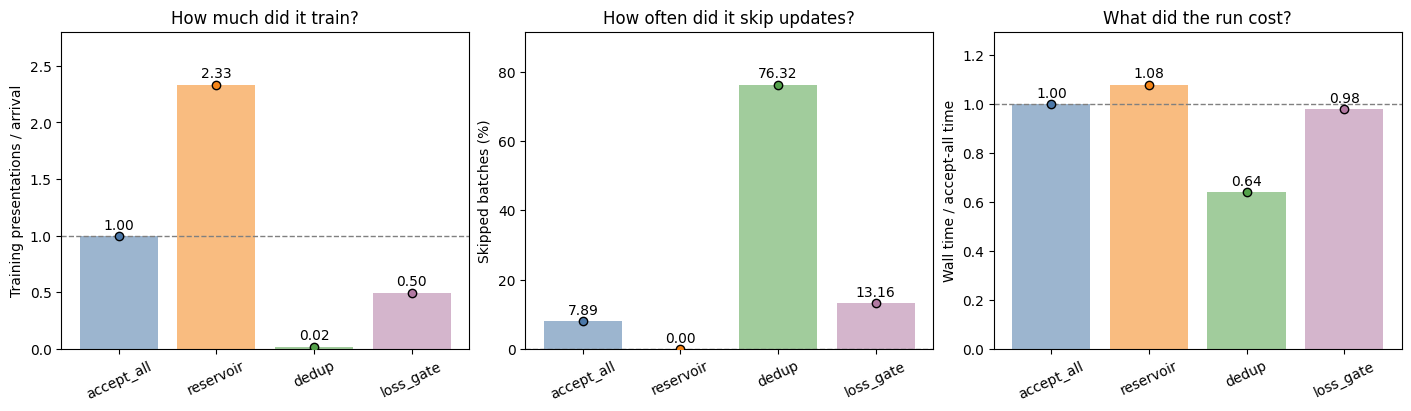

In [46]:
filter_colors = dict(zip(filter_names, ["#4c78a8", "#f58518", "#54a24b", "#b279a2"], strict=True))
batch_counts = selection_df.groupby(["filter", "seed"]).size().rename("incoming_batches").reset_index()
comparison_df = summary_df.merge(batch_counts, on=["filter", "seed"], validate="one_to_one")
comparison_df["skipped_percent"] = 100 * comparison_df["skipped_batches"] / comparison_df["incoming_batches"]
reference = comparison_df.loc[
    ~comparison_df["diverged"] & (comparison_df["filter"] == "accept_all"),
    ["seed", "wall_seconds", "final_knn_acc", "final_linear_acc"],
].rename(
    columns={
        "wall_seconds": "reference_seconds",
        "final_knn_acc": "reference_knn",
        "final_linear_acc": "reference_linear",
    }
)
comparison_df = comparison_df.merge(reference, on="seed", how="left", validate="many_to_one")
comparison_df["relative_runtime"] = comparison_df["wall_seconds"] / comparison_df["reference_seconds"]
for metric, reference_column in [("knn_acc", "reference_knn"), ("linear_acc", "reference_linear")]:
    comparison_df[f"vs_frozen_{metric}_pp"] = 100 * (
        comparison_df[f"final_{metric}"] - comparison_df[f"initial_{metric}"]
    )
    comparison_df[f"vs_accept_all_{metric}_pp"] = 100 * (
        comparison_df[f"final_{metric}"] - comparison_df[reference_column]
    )
comparison_df.to_csv(output_dir / "filter_comparison.csv", index=False)
query_count = len(preview.eval_sets.probe_query.images)
print(f"Query images: {query_count}; one changed prediction = {100 / query_count:.2f} percentage points.")
print(f"Seeds: {summary_df['seed'].nunique()}. Dots show individual runs; bars show means, not confidence intervals.")
show(
    comparison_df[
        [
            "filter",
            "seed",
            "diverged",
            "updates",
            "skipped_percent",
            "presentations_per_arrival",
            "relative_runtime",
            "vs_frozen_knn_acc_pp",
            "vs_frozen_linear_acc_pp",
            "vs_accept_all_knn_acc_pp",
            "vs_accept_all_linear_acc_pp",
        ]
    ].round(3)
)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, metric, title, reference_value in zip(
    axes,
    ["presentations_per_arrival", "skipped_percent", "relative_runtime"],
    ["How much did it train?", "How often did it skip updates?", "What did the run cost?"],
    [1, 0, 1],
    strict=True,
):
    for pos, name in enumerate(filter_names):
        values = comparison_df.loc[(comparison_df["filter"] == name) & ~comparison_df["diverged"], metric].dropna()
        if values.empty:
            continue
        ax.bar(pos, values.mean(), color=filter_colors[name], alpha=0.55)
        offsets = np.linspace(-0.12, 0.12, len(values)) if len(values) > 1 else [0]
        ax.scatter(pos + np.asarray(offsets), values, color=filter_colors[name], edgecolor="black", zorder=3)
        ax.annotate(
            f"{values.mean():.2f}", (pos, values.mean()), xytext=(0, 5), textcoords="offset points", ha="center"
        )
    ax.axhline(reference_value, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(filter_names)), filter_names, rotation=25)
    ax.set(
        title=title,
        ylabel={
            "presentations_per_arrival": "Training presentations / arrival",
            "skipped_percent": "Skipped batches (%)",
            "relative_runtime": "Wall time / accept-all time",
        }[metric],
    )
    ax.margins(y=0.2)
fig.savefig(output_dir / "comparison_work_dashboard.png", dpi=150)
plt.show()

## 2. Does the representation change in a useful way?

Read accuracy as **change from each run's frozen initialization**, in percentage points. Zero means adaptation supplied no gain. Positive values mean improvement on the fixed held-out scene queries; negative values mean loss. For example, 40% to 45% is +5 percentage points.

The first figure shows both the initial and final accuracies. The next figure separates the two questions that raw trajectories mixed together: **how quality changes as images arrive**, and **how quality changes per image presentation used for training**. Replay counts again each time an image is trained on. Equal presentations still do not imply equal compute, because scoring costs differ.

The final paired comparison subtracts the same seed's accept-all endpoint. Beating accept-all is not sufficient if both models lost quality relative to the frozen start. Keep both references in view.

**kNN** tests whether nearby features predict the same scene. **Linear accuracy** tests whether a simple fitted readout can extract scene information. Both use evaluation labels only. **Cosine drift** measures directional change of the representation; it is not a quality score. The drift-versus-quality plot shows why: moving further is useful only when quality also improves.

Markers are actual measurements. Dashed segments only connect them; no values are invented at missing checkpoints. Sparse filters may skip updates and therefore have fewer recorded health measurements. Reducing drift by barely training is not a selection success. RankMe remains available in `health.csv`, but is no longer placed on equal footing with downstream accuracy in this decision dashboard.

Probe resolution matters: with N fixed query images, one changed prediction moves accuracy by 100/N percentage points. The dashboard prints that resolution. Multiple seeds share this query set, so their spread captures training variation, not uncertainty over new evaluation images. No significance claim or automatic winner is produced.


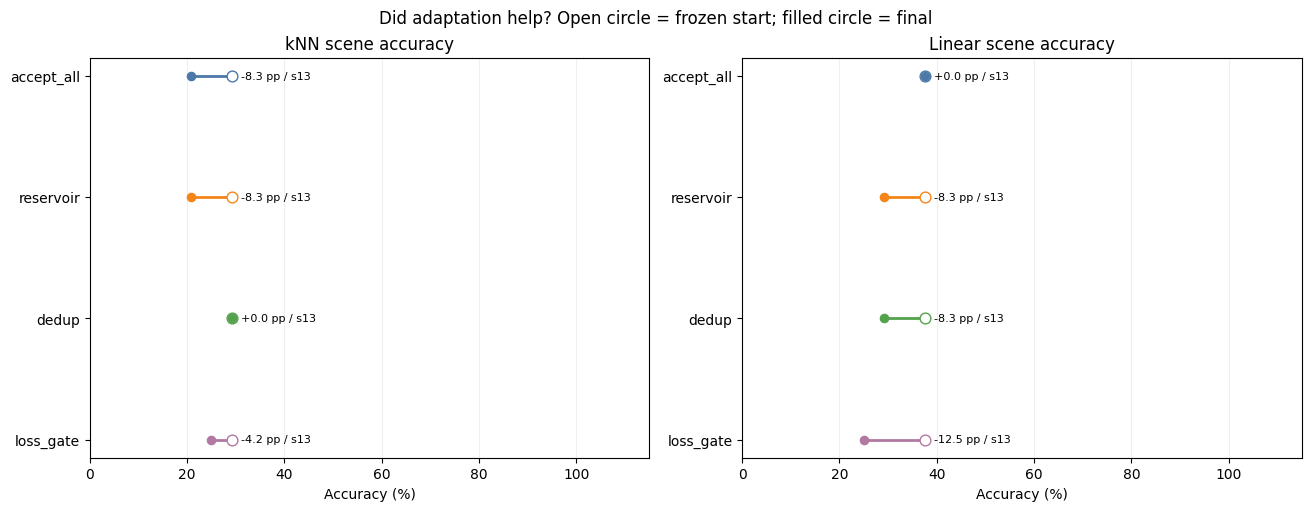

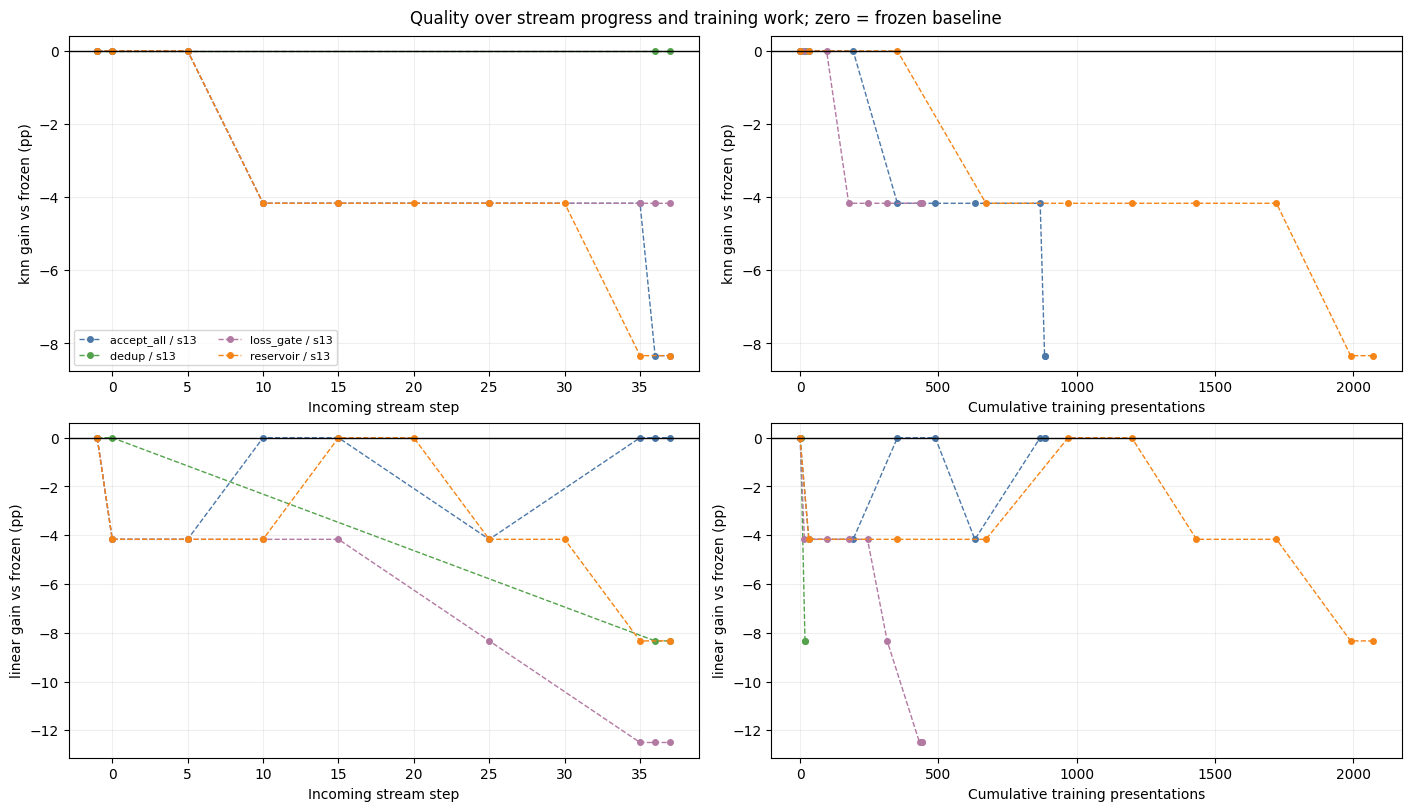

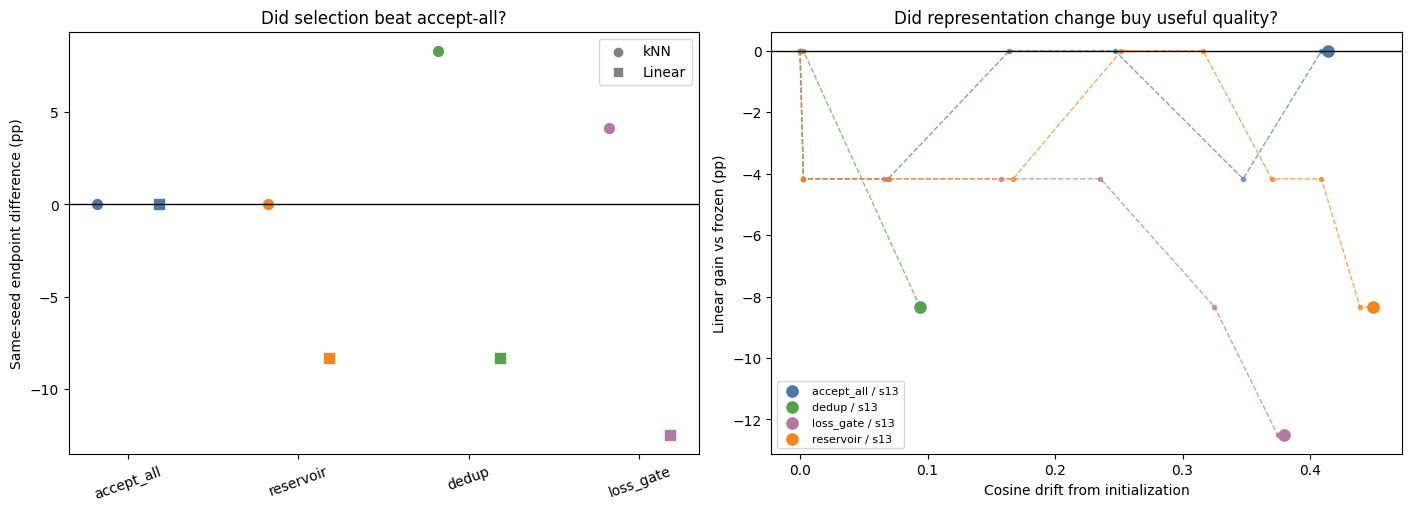

In [47]:
# Endpoint dumbbells: both absolute performance and direction of change remain visible.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, metric, title in zip(
    axes, ["knn_acc", "linear_acc"], ["kNN scene accuracy", "Linear scene accuracy"], strict=True
):
    for pos, name in enumerate(filter_names):
        rows = comparison_df.loc[(comparison_df["filter"] == name) & ~comparison_df["diverged"]]
        for offset, (_, result) in zip(
            np.linspace(-0.16, 0.16, len(rows)) if len(rows) > 1 else np.array([0.0]), rows.iterrows(), strict=True
        ):
            initial = 100 * result[f"initial_{metric}"]
            final = 100 * result[f"final_{metric}"]
            y = pos + offset
            ax.plot([initial, final], [y, y], color=filter_colors[name], linewidth=2)
            ax.scatter(initial, y, facecolors="white", edgecolors=filter_colors[name], s=60, zorder=3)
            ax.scatter(final, y, color=filter_colors[name], s=35, zorder=4)
            ax.annotate(
                f"{final - initial:+.1f} pp / s{int(result['seed'])}",
                (max(initial, final), y),
                xytext=(7, 0),
                textcoords="offset points",
                va="center",
                fontsize=8,
            )
    ax.set_yticks(range(len(filter_names)), filter_names)
    ax.invert_yaxis()
    ax.set(xlabel="Accuracy (%)", title=title)
    ax.set_xlim(0, 115)
    ax.grid(axis="x", alpha=0.2)
fig.suptitle("Did adaptation help? Open circle = frozen start; filled circle = final")
fig.savefig(output_dir / "initial_final_quality.png", dpi=150)
plt.show()

# Associate each actual health checkpoint with cumulative optimizer presentations.
trajectory_parts = []
for (name, seed), rows in health_df.groupby(["filter", "seed"]):
    ordered = rows.sort_values("step").drop_duplicates("step", keep="last").copy()
    base = comparison_df.loc[(comparison_df["filter"] == name) & (comparison_df["seed"] == seed)].iloc[0]
    exposure = selection_df.loc[(selection_df["filter"] == name) & (selection_df["seed"] == seed)].sort_values("step")
    cumulative = exposure.set_index("step")["trained"].cumsum()
    ordered["train_presentations"] = [0 if step < 0 else cumulative.loc[step] for step in ordered["step"]]
    for metric in ["knn_acc", "linear_acc"]:
        ordered[f"gain_{metric}_pp"] = 100 * (ordered[metric] - base[f"initial_{metric}"])
    trajectory_parts.append(ordered)
quality_trajectory = pd.concat(trajectory_parts, ignore_index=True)
quality_trajectory.to_csv(output_dir / "quality_trajectory.csv", index=False)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
for row_index, metric in enumerate(["knn_acc", "linear_acc"]):
    for col_index, clock in enumerate(["step", "train_presentations"]):
        ax = axes[row_index, col_index]
        for (name, seed), rows in quality_trajectory.groupby(["filter", "seed"]):
            ax.plot(
                rows[clock],
                rows[f"gain_{metric}_pp"],
                marker="o",
                markersize=4,
                linestyle="--",
                linewidth=1,
                color=filter_colors[name],
                label=f"{name} / s{seed}",
            )
        ax.axhline(0, color="black", linewidth=1)
        ax.set(
            xlabel="Incoming stream step" if clock == "step" else "Cumulative training presentations",
            ylabel=f"{metric.replace('_acc', '')} gain vs frozen (pp)",
        )
        ax.grid(alpha=0.2)
axes[0, 0].legend(fontsize=8, ncol=2)
fig.suptitle("Quality over stream progress and training work; zero = frozen baseline")
fig.savefig(output_dir / "quality_gain_trajectories.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for metric, marker in [("knn_acc", "o"), ("linear_acc", "s")]:
    for pos, name in enumerate(filter_names):
        rows = comparison_df.loc[(comparison_df["filter"] == name) & ~comparison_df["diverged"]]
        shifts = np.linspace(-0.1, 0.1, len(rows)) if len(rows) > 1 else np.array([0.0])
        axes[0].scatter(
            pos + (0.18 if metric == "linear_acc" else -0.18) + shifts,
            rows[f"vs_accept_all_{metric}_pp"],
            color=filter_colors[name],
            marker=marker,
            s=50,
        )
# Separate marker semantics from policy colors.
axes[0].scatter([], [], color="gray", marker="o", label="kNN")
axes[0].scatter([], [], color="gray", marker="s", label="Linear")
axes[0].set_xticks(range(len(filter_names)), filter_names, rotation=20)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(ylabel="Same-seed endpoint difference (pp)", title="Did selection beat accept-all?")
axes[0].legend()
for (name, seed), rows in quality_trajectory.groupby(["filter", "seed"]):
    axes[1].plot(
        rows["cosine_drift"],
        rows["gain_linear_acc_pp"],
        marker=".",
        linestyle="--",
        linewidth=1,
        color=filter_colors[name],
        alpha=0.7,
    )
    # Diverged endpoints are not presented as completed-run results.
    result = comparison_df.loc[(comparison_df["filter"] == name) & (comparison_df["seed"] == seed)].iloc[0]
    if not result["diverged"]:
        endpoint = rows.iloc[-1]
        axes[1].scatter(
            endpoint["cosine_drift"],
            endpoint["gain_linear_acc_pp"],
            color=filter_colors[name],
            s=65,
            label=f"{name} / s{seed}",
        )
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(
    xlabel="Cosine drift from initialization",
    ylabel="Linear gain vs frozen (pp)",
    title="Did representation change buy useful quality?",
)
axes[1].legend(fontsize=8)
fig.savefig(output_dir / "selection_value_and_drift.png", dpi=150)
plt.show()

## 3. What training work did each filter cause?

The left panel accumulates optimizer image presentations. A replayed image counts again each time it is used. The right panel counts batches that were too small to train on after selection. Each line represents one seed.

The heatmap breaks exposure down by the **arrival condition**. A value of 1 means one training presentation per incoming image; above 1 means replay added work; below 1 means admission filtering or skipped updates reduced it. Replay can contain images from older conditions, so a heatmap row does not describe the condition of every trained image.

Selected batches with fewer than two images contribute zero training presentations because the shared loop skips them. Check this before interpreting a flat health curve as stability.


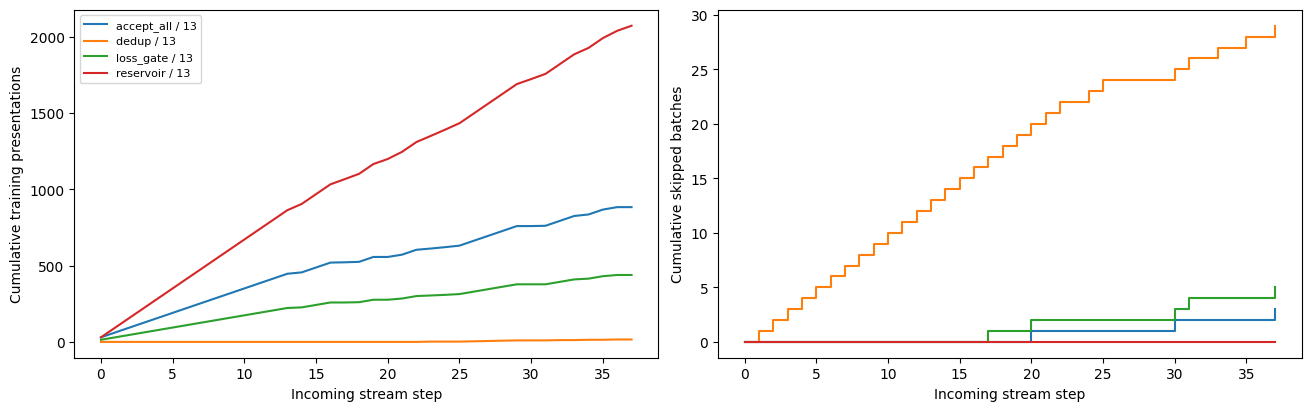

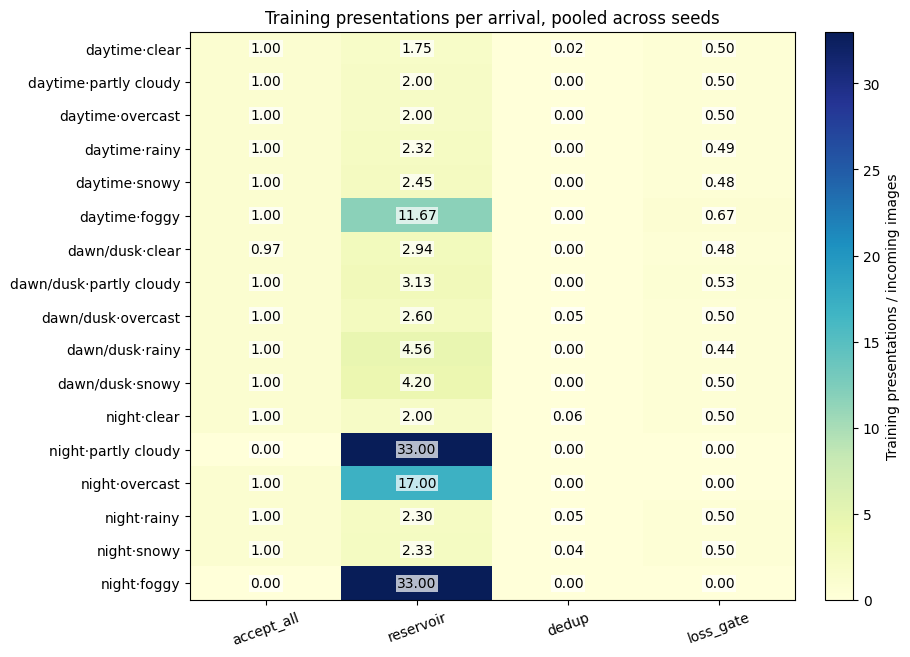

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for (name, seed), rows in selection_df.groupby(["filter", "seed"]):
    ordered = rows.sort_values("step")
    axes[0].plot(ordered["step"], ordered["trained"].cumsum(), label=f"{name} / {seed}")
    axes[1].step(ordered["step"], ordered["skipped"].cumsum(), where="post", label=f"{name} / {seed}")
axes[0].set(xlabel="Incoming stream step", ylabel="Cumulative training presentations")
axes[1].set(xlabel="Incoming stream step", ylabel="Cumulative skipped batches")
axes[0].legend(fontsize=8)
fig.savefig(output_dir / "training_exposure.png", dpi=150)
plt.show()

condition_totals = selection_df.groupby(["era", "filter"])[["trained", "arrivals"]].sum()
condition_totals["exposure"] = condition_totals["trained"] / condition_totals["arrivals"]
exposure_table = condition_totals["exposure"].unstack("filter").reindex(columns=filter_names)
fig, ax = plt.subplots(figsize=(9, max(4, len(exposure_table) * 0.38)), constrained_layout=True)
heat = ax.imshow(
    exposure_table.to_numpy(), aspect="auto", cmap="YlGnBu", vmin=0, vmax=max(1.0, float(exposure_table.max().max()))
)
ax.set_xticks(range(len(filter_names)), filter_names, rotation=20)
ax.set_yticks(range(len(exposure_table)), [preview.era_names[int(e)] for e in exposure_table.index])
ax.set_title("Training presentations per arrival, pooled across seeds")
for row in range(len(exposure_table)):
    for col in range(len(filter_names)):
        value = exposure_table.iloc[row, col]
        if pd.notna(value):
            ax.text(
                col,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="black",
                bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "pad": 1},
            )
fig.colorbar(heat, ax=ax, label="Training presentations / incoming images")
fig.savefig(output_dir / "condition_exposure.png", dpi=150)
stream_figure.savefig(output_dir / "stream_composition.png", dpi=150)
plt.show()

## 4. Is the quality worth the work?

The scatter plot compares elapsed time with final linear accuracy. Moving left means less measured runtime; moving up means higher scene accuracy. Each point is a filter/seed run. Runtime includes filtering, optimization, monitoring, and logging, but excludes loading the dataset and the initial probe measurement. GPU warm-up and execution order can affect short runs, so these are exploratory timings.

The paired plot subtracts the **same seed's accept-all** accuracy from each filter's final accuracy. Above zero means the filter finished ahead of accept-all on this probe; below zero means it finished behind. Differences are in percentage points: 0.50 to 0.55 is a gain of 5 points. Lines connect seeds only to make their paired comparisons easier to follow.

With several seeds, inspect whether the direction repeats. With one seed, do not treat a small gap as a reliable improvement. Diverged runs remain visible in the table and are excluded from quality comparisons. No automatic winner is declared.


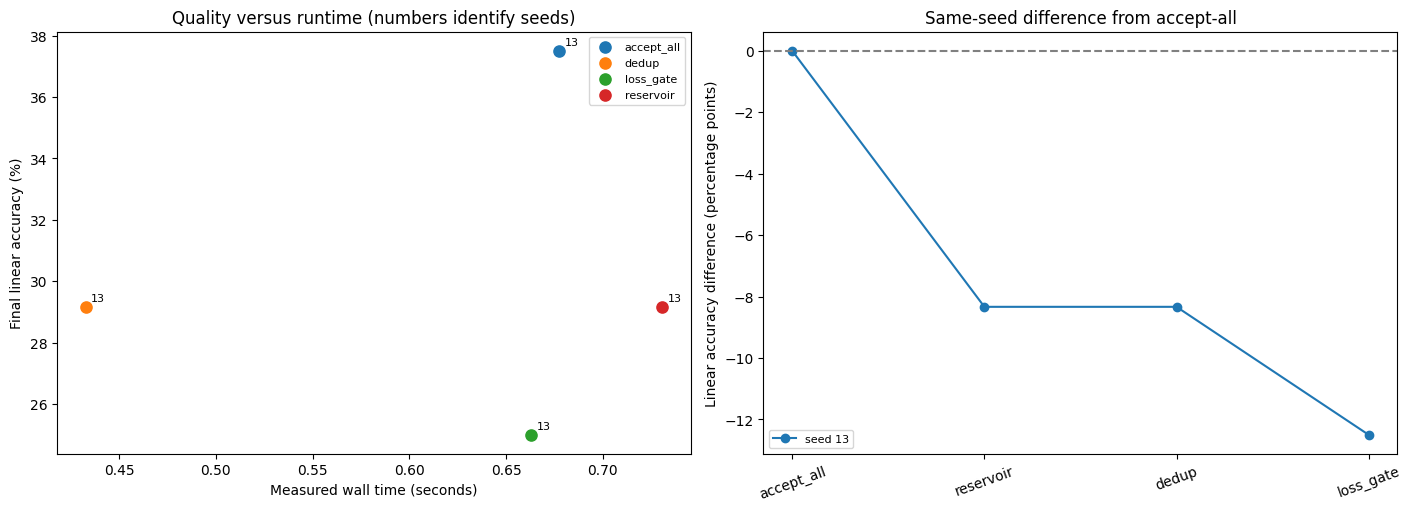

,filter,seed,device,diverged,updates,skipped_batches,train_presentations,wall_seconds,initial_linear_acc,final_linear_acc
0,accept_all,13,cuda,False,35,3,884,0.677416,0.375,0.375000
1,reservoir,13,cuda,False,38,0,2071,0.730671,0.375,0.291667
2,dedup,13,cuda,False,9,29,18,0.432768,0.375,0.291667
3,loss_gate,13,cuda,False,33,5,440,0.662863,0.375,0.250000


In [49]:
valid_summary = summary_df.loc[~summary_df["diverged"]].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for name, rows in valid_summary.groupby("filter"):
    axes[0].scatter(rows["wall_seconds"], 100 * rows["final_linear_acc"], label=name, s=65)
    for _, result in rows.iterrows():
        axes[0].annotate(
            str(int(result["seed"])),
            (result["wall_seconds"], 100 * result["final_linear_acc"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )
axes[0].set(
    xlabel="Measured wall time (seconds)",
    ylabel="Final linear accuracy (%)",
    title="Quality versus runtime (numbers identify seeds)",
)
axes[0].legend(fontsize=8)
reference = valid_summary.loc[valid_summary["filter"] == "accept_all", ["seed", "final_linear_acc"]].rename(
    columns={"final_linear_acc": "accept_all_linear_acc"}
)
paired_df = valid_summary.merge(reference, on="seed", how="inner", validate="many_to_one")
paired_df["delta_vs_accept_all_pp"] = 100 * (paired_df["final_linear_acc"] - paired_df["accept_all_linear_acc"])
for seed, rows in paired_df.groupby("seed"):
    values = rows.set_index("filter").reindex(filter_names)["delta_vs_accept_all_pp"]
    axes[1].plot(range(len(filter_names)), values, marker="o", label=f"seed {seed}")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_xticks(range(len(filter_names)), filter_names, rotation=20)
axes[1].set(ylabel="Linear accuracy difference (percentage points)", title="Same-seed difference from accept-all")
if not paired_df.empty:
    axes[1].legend(fontsize=8)
fig.savefig(output_dir / "quality_cost.png", dpi=150)
paired_df.to_csv(output_dir / "paired_comparison.csv", index=False)
plt.show()
show(
    summary_df[
        [
            "filter",
            "seed",
            "device",
            "diverged",
            "updates",
            "skipped_batches",
            "train_presentations",
            "wall_seconds",
            "initial_linear_acc",
            "final_linear_acc",
        ]
    ]
)

## Reading the results together

1. **Check that learning happened.** A filter with many skipped batches may simply preserve the initial model. That is not evidence that its selections are better.
2. **Compare both quality references.** Improvement over the frozen initialization asks whether adaptation helped. Improvement over accept-all asks whether the filter helped relative to training on every arrival.
3. **Account for work.** Reservoir replay can buy quality with more training presentations. Deduplication and loss gating can reduce presentations while adding scoring overhead. Image counts and measured runtime answer different questions.
4. **Look for repeated evidence.** Expand `seeds` before trusting small differences. Keep the data, probe reservation, model and device fixed when comparing filters.

This notebook does not test whether old conditions are forgotten: its probe is a global scene task. That would require condition-specific evaluation over time. It also does not certify degradation from RankMe or drift alone. These figures help decide whether a larger, controlled follow-up is worth running.

All figures are saved as PNG files beside `summary.csv`, `health.csv`, `selection.csv`, `paired_comparison.csv`, the resolved `config.json`, and per-arm logs. Rerun the notebook from the top after changing settings so the plotted results and configuration agree.


# P1.3 continuation: does selection change retention?

This section replaces the random-start pilot as the scientific follow-up. It tests **selection at a fixed optimizer-image budget**, from one shared warmed MAE, under blocked and shuffled versions of exactly the same image pool.

P1.3 asks how correlation and horizon affect forgetting, and whether selection changes that effect. P1.1 still needs a calibrated reading protocol. P1.2's later results report improved retention with replay but an unresolved joint quality gate; its index/detail and latest-results summary disagree about the latest state. This notebook is therefore **development evidence**, not a Phase 1 Go decision. It does not supply a calibrated positive control or the MAE fine-tuning corroboration required for a formal claim.

The experiment has four adapting arms: accept-all without replay, random current selection with replay, semantic deduplication with replay, and high-loss selection with replay. Each starts from the identical full-method state. A measured frozen copy of that state supplies the reference. For the three replay arms, every arrival enters a uniform reservoir; only the current-image choice differs.

**Why the random arm matters:** keeping fewer images can change learning by itself. The random arm keeps the same number as the informed arms, so their comparison asks whether the choice of images matters.

**Deduplication at a fixed quota:** first keep the stock greedy similarity-threshold survivors. If too many survive, subsample them; if too few survive, fill the quota randomly from rejected images. We record the number of survivors before filling. This is a controlled quota experiment, not the unmodified stock admission filter.


In [50]:
from collections.abc import Iterator

from cafl4ds.eval import PerEraProbe
from cafl4ds.filters.dedup import semantic_dedup_keep
from cafl4ds.ssl.base import SSLMethod
from cafl4ds.warmup import load_well, save_well, warm_until_settled

p13_seeds = [13]  # Development only. Freeze settings before choosing fresh confirmation seeds.
p13_orders = ["blocked", "shuffled"]
p13_filters = ["accept_all", "random_replay", "dedup_replay", "loss_replay"]
p13_train_cap = 5000  # Source caches images in RAM; None loads the full split.
p13_val_cap = 2000
p13_per_condition = 128  # Horizon knob: later compare larger caps with the same protocol.
p13_eval_every = 10
p13_condition_queries = 8  # Maximum per (condition, scene); actual counts are saved.
p13_partition_seed = 20260921
p13_warm_fraction = 0.2
p13_warm_seed = 101
p13_current_quota = batch_size // 2
p13_replay_quota = batch_size - p13_current_quota
p13_dedup_threshold = 0.9  # Stock starting point; calibrate on development data only.
p13_well_path = None  # Optional compatible full-method checkpoint; never silently loads a stale well.
p13_warm_steps = 200  # Capped pilot warm-up; a plateau is not a competence certificate.
p13_dir = repo_root / "outputs" / "p13-selection-pilot" / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
p13_dir.mkdir(parents=True, exist_ok=False)
if batch_size < 2 or p13_current_quota < 1 or p13_replay_quota < 1:
    raise ValueError("Current and replay quotas must both be positive.")

## Separate warm-up, stream and evaluation data

Official train is split deterministically into a warm-up partition (20%) and its complementary stream partition (80%). The same partition seed and fraction must be used for both. Official validation supplies every labeled probe; test is untouched. Caps make this a development subset and may underrepresent rare conditions.

A supplied checkpoint must match `method_cfg` and must have been trained only on the stated warm partition (or independent pretraining data). The loader checks model shapes, not data provenance: record that provenance below. With no checkpoint supplied, this section warms a new full MAE locally and saves it. It never treats a failed checkpoint load as permission to use random weights.


In [51]:
def p13_source_config(split: str, role: str | None, cap: int | None) -> dict[str, Any]:
    """Build matching BDD source specifications for independent train and validation roles."""
    return {
        "_target_": "cafl4ds.data.attributes.BDD100KSource",
        "bdd_root": str(bdd_root),
        "split": split,
        "img_size": img_size,
        "images_dir": str(bdd_root / "images" / "100k" / split),
        "labels_file": str(bdd_root / "labels" / f"bdd100k_labels_images_{split}.json"),
        "max_images": cap,
        "min_canary_count": min_canary_count,
        "partition_role": role,
        "warm_fraction": p13_warm_fraction,
        "partition_seed": p13_partition_seed,
    }


p13_warm_cfg = p13_source_config("train", "warm", p13_train_cap)
p13_train_cfg = p13_source_config("train", "stream", p13_train_cap)
p13_val_cfg = p13_source_config("val", None, p13_val_cap)
p13_train_source = instantiate(p13_train_cfg)
p13_val_source = instantiate(p13_val_cfg)
p13_stream_cfg = OmegaConf.create(
    {
        "_target_": "cafl4ds.data.regime.RegimeStream",
        "batch_size": batch_size,
        "support_per_canary": support_per_canary,
        "query_per_canary": query_per_canary,
        "era_query_per_cell": p13_condition_queries,
        "canary_seed": canary_seed,
        "max_train_per_regime": p13_per_condition,
    }
)
p13_reference_stream = instantiate(
    p13_stream_cfg, source=p13_train_source, evaluation_source=p13_val_source, seed=p13_seeds[0]
)
if not len(p13_reference_stream) or len(p13_reference_stream.eval_sets.per_era) < 2:
    raise ValueError(
        "Need training batches and at least two conditions with validation queries; increase the data caps."
    )
seed_all(p13_warm_seed)
p13_start = instantiate(method_cfg).to(device)
if p13_well_path is None:
    warm_stream = instantiate(
        p13_stream_cfg, source=instantiate(p13_warm_cfg), evaluation_source=p13_val_source, seed=p13_warm_seed
    )
    warm_report = warm_until_settled(
        method=p13_start,
        stream=warm_stream,
        optimizer=instantiate(optimizer_cfg, params=p13_start.parameters()),
        max_steps=p13_warm_steps,
        device=device,
    )
    if warm_report["steps"] == 0 or not np.isfinite(warm_report["loss_trace"]).all():
        raise RuntimeError("Warm-up did not produce finite updates; no selection run will start.")
    save_well(p13_start, p13_dir / "development_well.pt")
else:
    load_well(p13_start, Path(p13_well_path))
    warm_report = {"source_checkpoint": str(p13_well_path), "competence": "must be independently verified"}
p13_initial_state = {key: value.detach().cpu().clone() for key, value in p13_start.state_dict().items()}
del p13_start
show(warm_report)
condition_sizes = pd.DataFrame(
    [
        {
            "condition": era,
            "name": p13_reference_stream.era_names[era],
            "query_images": len(part.images),
            "scene_classes": int(part.labels.unique().numel()),
        }
        for era, part in p13_reference_stream.eval_sets.per_era.items()
    ]
)
condition_sizes.to_csv(p13_dir / "condition_query_sizes.csv", index=False)
show(condition_sizes)

2026-09-28 22:08:09.299 | INFO     | cafl4ds.data.attributes:_drop_rare_scenes:455 - BDD100KSource: dropped rare scenes below min_canary_count=32: ['gas stations', 'tunnel']
2026-09-28 22:08:27.679 | INFO     | cafl4ds.data.attributes:_decode:332 - BDD100KSource: loaded 3995 images (train) at 64px over 18 regimes, 4 scenes
2026-09-28 22:08:28.852 | INFO     | cafl4ds.data.attributes:_drop_rare_scenes:455 - BDD100KSource: dropped rare scenes below min_canary_count=32: ['gas stations', 'parking lot', 'tunnel']
2026-09-28 22:08:37.882 | INFO     | cafl4ds.data.attributes:_decode:332 - BDD100KSource: loaded 1987 images (val) at 64px over 17 regimes, 3 scenes
2026-09-28 22:08:46.255 | INFO     | cafl4ds.data.attributes:_drop_rare_scenes:455 - BDD100KSource: dropped rare scenes below min_canary_count=32: ['gas stations', 'tunnel']
2026-09-28 22:08:50.914 | INFO     | cafl4ds.data.attributes:_decode:332 - BDD100KSource: loaded 1002 images (train) at 64px over 15 regimes, 4 scenes
2026-09-28 2

{'steps': 200,
 'plateaued': False,
 'init_loss': 1.212697285413742,
 'final_loss': 0.9423255831003189,
 'loss_trace': [1.2690118551254272,
  1.262623906135559,
  1.2523881196975708,
  1.2509685754776,
  1.2439531087875366,
  1.2344200611114502,
  1.239712119102478,
  1.2203007936477661,
  1.2186089754104614,
  1.206239104270935,
  1.2051819562911987,
  1.1926153898239136,
  1.1964229345321655,
  1.1911768913269043,
  1.1858290433883667,
  1.1811280250549316,
  1.1841217279434204,
  1.176434874534607,
  1.169406771659851,
  1.1734014749526978,
  1.1611024141311646,
  1.1506164073944092,
  1.1578572988510132,
  1.1517635583877563,
  1.156487226486206,
  1.1508015394210815,
  1.150563359260559,
  1.14511239528656,
  1.144781470298767,
  1.1330376863479614,
  1.1321409940719604,
  1.134355068206787,
  1.1410017013549805,
  1.13350248336792,
  1.1269044876098633,
  1.1211744546890259,
  1.1283897161483765,
  1.1155978441238403,
  1.1154695749282837,
  1.1015528440475464,
  1.12333214282989

,condition,name,query_images,scene_classes
0,0,daytime·clear,24,3
1,1,daytime·partly cloudy,24,3
2,2,daytime·overcast,24,3
3,3,daytime·rainy,24,3
4,4,daytime·snowy,24,3
5,5,daytime·foggy,1,1
6,6,dawn/dusk·clear,24,3
7,7,dawn/dusk·partly cloudy,17,3
8,8,dawn/dusk·overcast,22,3
9,9,dawn/dusk·rainy,13,3


## Matched selection and stream controls

All replay arms train on at most half a batch of current images plus half a batch from history. Replay is sampled before admitting the current arrivals. The reservoir stores **every** arrival, so a current-image rejection does not erase that image from future replay. All three arms use the same reservoir seed and admission sequence within an order/seed pair.

The shuffled control globally permutes the blocked stream's exact image pool, then restores the blocked stream's batch-size sequence. This matches arrivals, update opportunities and tail-batch sizes. It avoids mistaking a larger effective batch for an ordering benefit. Shuffled batches have no chronological condition labels; their condition-specific measurements are still available, but chronological backward transfer is reported only for the blocked stream.

The accept-all arm is contextual: it uses every current image with no replay. The clean selection comparison is between the three quota-matched replay arms. All use a constant learning rate, one pass and no learning-rate restarts. Total runtime remains different because informed scoring adds overhead.


In [52]:
class P13Order:
    """Present one fixed training pool with matched batch sizes in two orders."""

    def __init__(self, stream: RegimeStream, order: str, seed: int) -> None:
        """Record batch shapes; shuffle image indices using an isolated generator."""
        self.batches = list(stream)
        self.order = order
        self.images = None
        if order == "shuffled":
            images = torch.cat([batch.images for batch in self.batches])
            indices = torch.randperm(len(images), generator=torch.Generator().manual_seed(seed))
            self.images = images[indices]
        elif order != "blocked":
            raise ValueError(f"Unknown order: {order}")

    def __len__(self) -> int:
        """Return the matched incoming-batch horizon."""
        return len(self.batches)

    def __iter__(self) -> Iterator[StreamBatch]:
        """Yield identically sized batches, tagging shuffled batches as a single era."""
        offset = 0
        for step, batch in enumerate(self.batches):
            count = len(batch.images)
            images = batch.images if self.images is None else self.images[offset : offset + count]
            yield StreamBatch(images=images, era=batch.era if self.order == "blocked" else 0, step=step)
            offset += count


class P13Selector(Filter):
    """Choose current images at a fixed quota while preserving common reservoir admission."""

    def __init__(self, policy: str, seed: int) -> None:
        """Use independent random generators for current selection and historical replay."""
        self.policy = policy
        self.generator = torch.Generator().manual_seed(seed + 10000)
        self.buffer = instantiate(
            {
                "_target_": "cafl4ds.filters.reservoir.ReservoirReplay",
                "capacity": 256,
                "replay_batch": p13_replay_quota,
                "seed": seed,
            }
        )
        self.trace: list[dict[str, int]] = []

    def select(self, batch: StreamBatch, ctx: FilterContext) -> torch.Tensor:
        """Score only current images, replay genuine history, then admit every arrival."""
        images = batch.images
        count = len(images)
        quota = min(p13_current_quota, count)
        survivors = count
        if self.policy == "accept_all":
            selected = images
        else:
            random_order = torch.randperm(count, generator=self.generator).tolist()
            if self.policy == "random_replay":
                chosen = random_order[:quota]
            elif self.policy == "dedup_replay":
                was_training = ctx.method.training
                ctx.method.eval()
                try:
                    candidates = semantic_dedup_keep(ctx.method.encode(images), p13_dedup_threshold).tolist()
                finally:
                    ctx.method.train(was_training)
                survivors = len(candidates)
                candidate_set = set(candidates)
                preferred = [i for i in random_order if i in candidate_set]
                fallback = [i for i in random_order if i not in candidate_set]
                chosen = (preferred + fallback)[:quota]
            elif self.policy == "loss_replay":
                chosen = ctx.method.per_sample_loss(images).topk(quota).indices.tolist()
            else:
                raise ValueError(f"Unknown policy: {self.policy}")
            # The buffer returns all current images followed by past replay.
            # Discard its current prefix, replacing it with the quota-selected current images.
            combined = self.buffer.observe(images, ctx)
            selected = torch.cat([images[sorted(chosen)], combined[count:]], dim=0)
        self.trace.append(
            {
                "step": batch.step,
                "arrivals": count,
                "selected": len(selected),
                "trained": len(selected) if len(selected) >= 2 else 0,
                "dedup_survivors": survivors,
            }
        )
        return selected


class P13Monitor(HealthMonitor):
    """Read every held-out condition on the same global checkpoint clock."""

    def measure(self, method: SSLMethod, step: int) -> dict[str, float]:
        """Add fixed-condition kNN reads without feeding labels to selection."""
        result = super().measure(method, step)
        probe = PerEraProbe(self.eval_sets, probe="knn", knn_k=5)
        was_training = method.training
        method.eval()
        try:
            row = probe.record(method.encode, max(self.eval_sets.per_era))
        finally:
            method.train(was_training)
        result.update({f"condition_{era}_knn": acc for era, acc in row.items()})
        return result

In [53]:
def run_p13(order: str, policy: str, seed: int) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    """Run a paired warm-start selection arm with condition-specific retention evaluation."""
    seed_all(seed)
    stream = instantiate(p13_stream_cfg, source=p13_train_source, evaluation_source=p13_val_source, seed=seed)
    ordered = P13Order(stream, order, seed)
    method = instantiate(method_cfg).to(device)
    method.load_state_dict(p13_initial_state, strict=True)
    selector = P13Selector(policy, seed)
    eval_sets = make_monitor(stream).eval_sets
    monitor = P13Monitor(eval_sets, knn_k=5, run_alignment=False)
    initial = monitor.measure(method, -1)
    past_probe = PerEraProbe(eval_sets, probe="knn", knn_k=5) if order == "blocked" else None
    seed_all(seed)
    if device == "cuda":
        torch.cuda.synchronize()
    start = perf_counter()
    name = f"{order}_{policy}_s{seed}"
    arm = run_stream_arm(
        name=name,
        role="live",
        method=method,
        stream=ordered,
        optimizer=instantiate(optimizer_cfg, params=method.parameters()),
        selection_filter=selector,
        monitor=monitor,
        out_dir=p13_dir,
        eval_every=p13_eval_every,
        device=device,
        era_evaluator=past_probe,
    )
    final = monitor.measure(method, len(ordered) - 1) if not arm.diverged else {}
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = perf_counter() - start
    metrics = past_probe.summary() if past_probe is not None and not arm.diverged else {}
    if past_probe is not None:
        (p13_dir / f"{name}_retention.json").write_text(
            dumps_valid({"matrix": past_probe.matrix, "summary": metrics, "diverged": arm.diverged}), encoding="utf-8"
        )
    trace = pd.DataFrame(selector.trace)
    trace.to_csv(p13_dir / f"{name}_selection.csv", index=False)
    summary = {
        "order": order,
        "filter": policy,
        "seed": seed,
        "device": device,
        "diverged": arm.diverged,
        "updates": len(arm.loss_records),
        "wall_seconds": elapsed,
        "train_presentations": int(trace["trained"].sum()),
        "bwt": metrics.get("backward_transfer"),
        "forgetting": metrics.get("forgetting_measure"),
    }
    for metric in ["knn_acc", "linear_acc"]:
        summary[f"initial_{metric}"] = initial[metric]
        summary[f"final_{metric}"] = final.get(metric, float("nan"))
        summary[f"gain_{metric}"] = summary[f"final_{metric}"] - initial[metric]
    # Keep a measured frozen reference at every checkpoint; its encoder never changes.
    health = [{"order": order, "filter": policy, "seed": seed, **initial}]
    health.extend({"order": order, "filter": policy, "seed": seed, **r} for r in arm.health)
    if final:
        health = [r for r in health if r["step"] != final["step"]]
        health.append({"order": order, "filter": policy, "seed": seed, **final})
    for record in health:
        record.update({f"frozen_{key}": value for key, value in initial.items() if key != "step"})
    return summary, health


p13_manifest = {
    "status": "exploratory P1.3-aligned development pilot; no phase gate evaluated",
    "warm_source": p13_warm_cfg,
    "train_source": p13_train_cfg,
    "validation_source": p13_val_cfg,
    "warm_report": warm_report,
    "warm_seed": p13_warm_seed,
    "seeds": p13_seeds,
    "orders": p13_orders,
    "filters": p13_filters,
    "current_quota": p13_current_quota,
    "replay_quota": p13_replay_quota,
    "reservoir_capacity": 256,
    "reservoir_admission": "all arrivals",
    "dedup_threshold": p13_dedup_threshold,
    "device": device,
    "eval_every": p13_eval_every,
    "method": OmegaConf.to_container(method_cfg, resolve=True),
    "optimizer": OmegaConf.to_container(optimizer_cfg, resolve=True),
    "stream": OmegaConf.to_container(p13_stream_cfg, resolve=True),
}
(p13_dir / "config.json").write_text(dumps_valid(p13_manifest), encoding="utf-8")
p13_summaries, p13_health_rows = [], []
for seed in p13_seeds:
    for order in p13_orders:
        for policy in p13_filters:
            logger.info("P1.3 pilot: {} / {} / seed {}", order, policy, seed)
            result, readings = run_p13(order, policy, seed)
            p13_summaries.append(result)
            p13_health_rows.extend(readings)
            pd.DataFrame(p13_summaries).to_csv(p13_dir / "summary.csv", index=False)
            pd.DataFrame(p13_health_rows).to_csv(p13_dir / "health.csv", index=False)
p13_summary = pd.DataFrame(p13_summaries)
p13_health = pd.DataFrame(p13_health_rows)
show(p13_summary)

2026-09-28 22:08:53.153 | INFO     | __main__:<module>:95 - P1.3 pilot: blocked / accept_all / seed 13
2026-09-28 22:08:53.404 | INFO     | cafl4ds.run_log:log_health:86 - [blocked_accept_all_s13] health step=0.0000 era=0.0000 loss=0.9516 rankme=4.7550 cka_drift=0.0028 cosine_drift=0.0066 knn_acc=0.5417 linear_acc=0.4167
2026-09-28 22:08:53.618 | INFO     | cafl4ds.run_log:log_health:86 - [blocked_accept_all_s13] health step=10.0000 era=2.0000 loss=0.9568 rankme=4.7047 cka_drift=0.0008 cosine_drift=0.0022 knn_acc=0.5417 linear_acc=0.4167
2026-09-28 22:08:53.870 | INFO     | cafl4ds.run_log:log_health:86 - [blocked_accept_all_s13] health step=20.0000 era=5.0000 loss=0.9490 rankme=4.7655 cka_drift=0.0009 cosine_drift=0.0022 knn_acc=0.5417 linear_acc=0.4167
2026-09-28 22:08:53.985 | DEBUG    | cafl4ds.loop:_step_on_batch:168 - step 26: skipping batch of 1 (< 2).
2026-09-28 22:08:54.198 | INFO     | cafl4ds.run_log:log_health:86 - [blocked_accept_all_s13] health step=30.0000 era=9.0000 los

,order,filter,seed,device,diverged,updates,wall_seconds,train_presentations,bwt,forgetting,initial_knn_acc,final_knn_acc,gain_knn_acc,initial_linear_acc,final_linear_acc,gain_linear_acc
0,blocked,accept_all,13,cuda,False,45,1.896224,1315,-0.007412,0.012620,0.541667,0.541667,0.000000,0.416667,0.375,-0.041667
1,blocked,random_replay,13,cuda,False,48,2.027383,1436,0.001532,0.017369,0.541667,0.541667,0.000000,0.416667,0.375,-0.041667
2,blocked,dedup_replay,13,cuda,False,48,2.319674,1436,0.003735,0.014093,0.541667,0.541667,0.000000,0.416667,0.375,-0.041667
3,blocked,loss_replay,13,cuda,False,48,2.088165,1436,-0.008885,0.014093,0.541667,0.500000,-0.041667,0.416667,0.375,-0.041667
4,shuffled,accept_all,13,cuda,False,45,1.119059,1315,NaN,NaN,0.541667,0.541667,0.000000,0.416667,0.375,-0.041667
5,shuffled,random_replay,13,cuda,False,48,1.251999,1436,NaN,NaN,0.541667,0.541667,0.000000,0.416667,0.375,-0.041667
6,shuffled,dedup_replay,13,cuda,False,48,1.554645,1436,NaN,NaN,0.541667,0.541667,0.000000,0.416667,0.375,-0.041667
7,shuffled,loss_replay,13,cuda,False,48,1.360502,1436,NaN,NaN,0.541667,0.500000,-0.041667,0.416667,0.375,-0.041667


## Read retention, not just feature movement

The matrices below show **change from the frozen warm model**, in percentage points, on each fixed validation condition. Rows are conditions; columns are actual stream checkpoints. A red row that becomes more negative indicates loss relative to the starting representation. It is not necessarily forgetting of something acquired online: for that, inspect the blocked-stream BWT and forgetting measures too.

BWT compares each earlier condition's final score with its score just after its learning block. Negative BWT means later learning erased some of that gain. The repository's forgetting measure compares the best earlier checkpoint with the final score; it is signed and can be negative when the final score exceeds all previous ones. Shuffled-stream BWT/forgetting are left undefined because shuffled data has no chronological condition-learning boundary.

Global linear-probe gain and forgetting must be read together. A filter can reduce forgetting simply by learning less. Query counts differ between conditions; rare conditions may have only one scene class and very noisy accuracies. The saved query-size table makes that limitation visible. These kNN retention plots do not replace a MAE fine-tuning probe or a calibrated positive control.


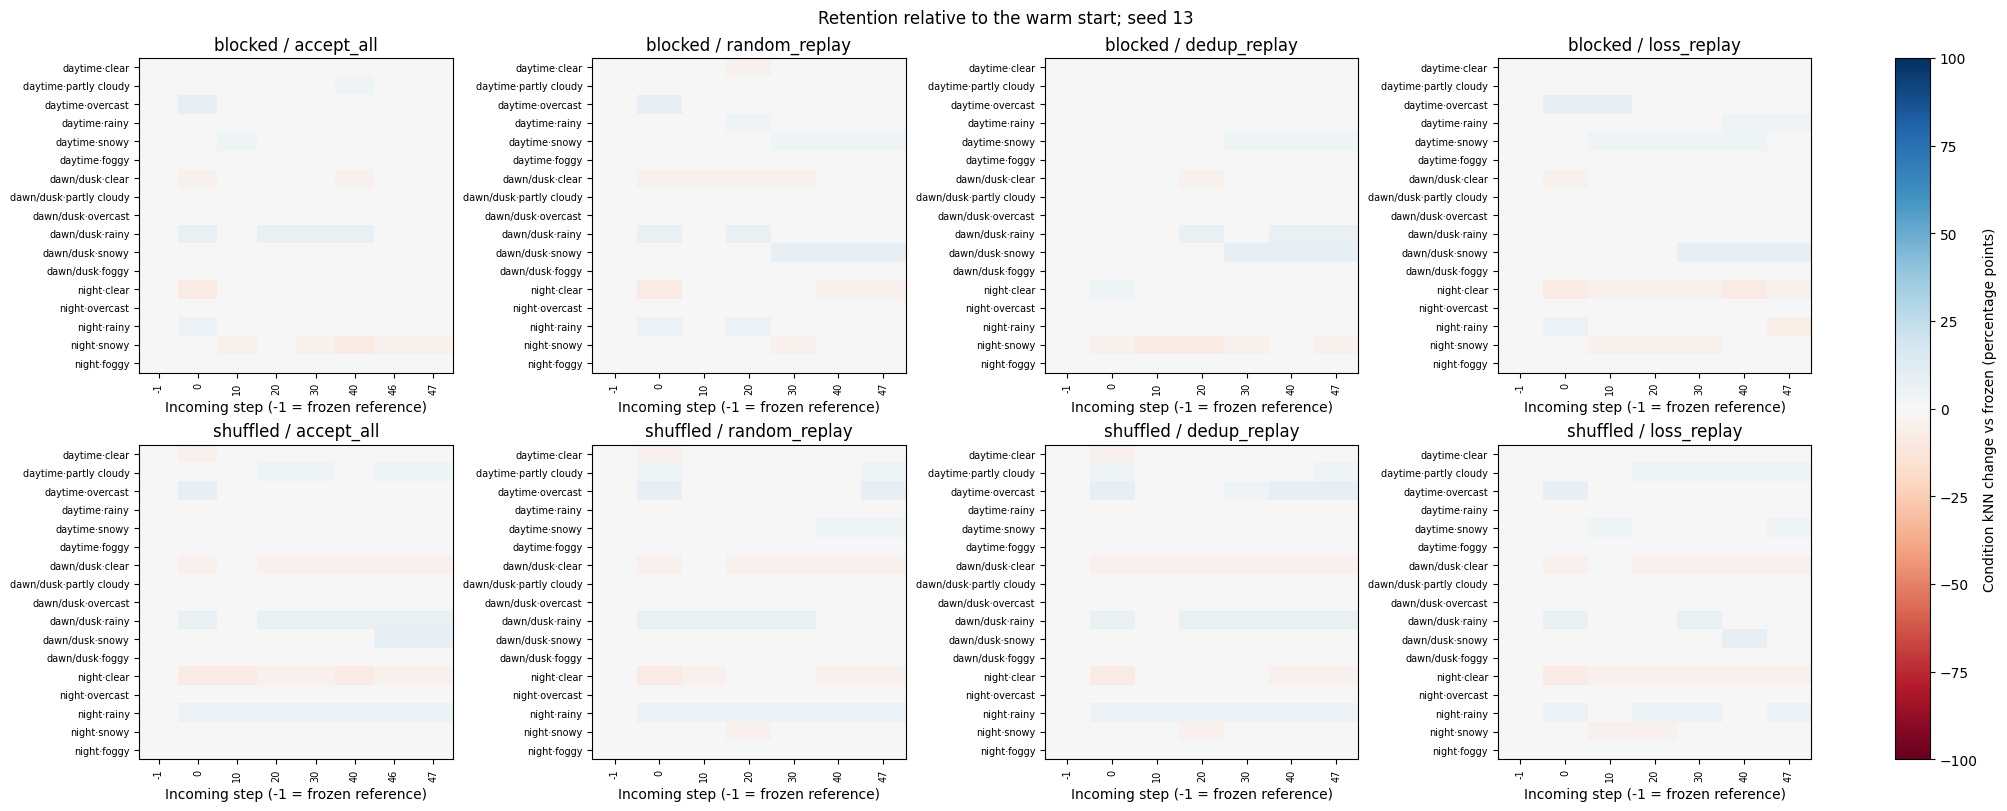

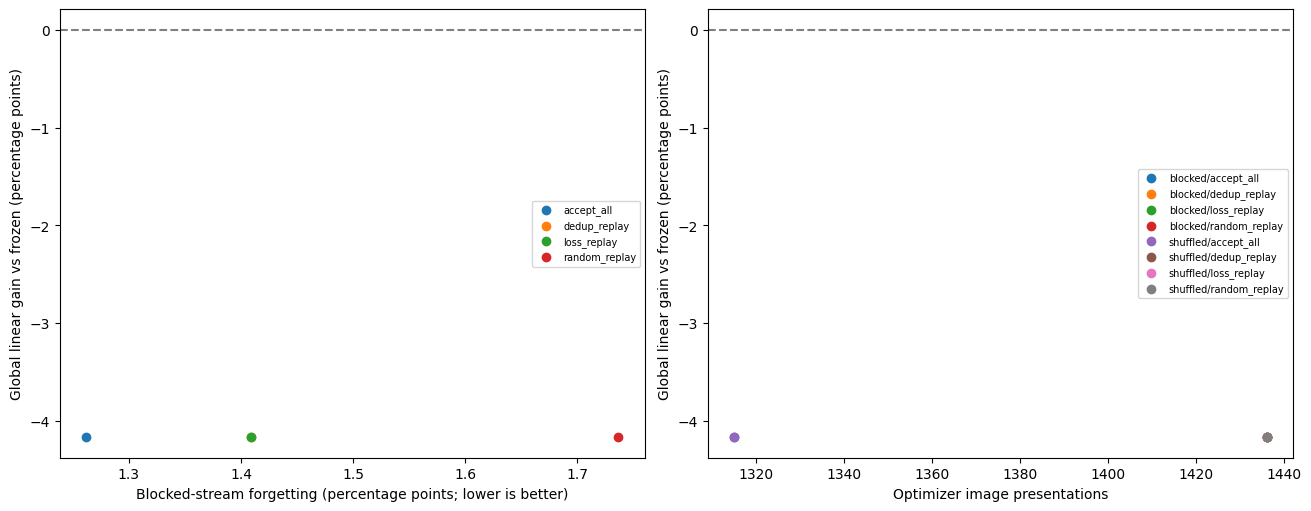

,order,filter,seed,diverged,updates,train_presentations,gain_knn_acc,gain_linear_acc,bwt,forgetting,wall_seconds
0,blocked,accept_all,13,False,45,1315,0.000000,-0.041667,-0.007412,0.012620,1.896224
1,blocked,random_replay,13,False,48,1436,0.000000,-0.041667,0.001532,0.017369,2.027383
2,blocked,dedup_replay,13,False,48,1436,0.000000,-0.041667,0.003735,0.014093,2.319674
3,blocked,loss_replay,13,False,48,1436,-0.041667,-0.041667,-0.008885,0.014093,2.088165
4,shuffled,accept_all,13,False,45,1315,0.000000,-0.041667,NaN,NaN,1.119059
5,shuffled,random_replay,13,False,48,1436,0.000000,-0.041667,NaN,NaN,1.251999
6,shuffled,dedup_replay,13,False,48,1436,0.000000,-0.041667,NaN,NaN,1.554645
7,shuffled,loss_replay,13,False,48,1436,-0.041667,-0.041667,NaN,NaN,1.360502


P1.3 development outputs: c:\Users\muham\Documents\cafl4ds\outputs\p13-selection-pilot\20260928T200800350523Z


In [54]:
p13_plot_seed = p13_seeds[0]
condition_columns = [c for c in p13_health if c.startswith("condition_") and c.endswith("_knn")]
fig, axes = plt.subplots(
    len(p13_orders),
    len(p13_filters),
    figsize=(5 * len(p13_filters), 4 * len(p13_orders)),
    squeeze=False,
    constrained_layout=True,
)
for row_index, order in enumerate(p13_orders):
    for col_index, policy in enumerate(p13_filters):
        rows = p13_health.loc[
            (p13_health["seed"] == p13_plot_seed) & (p13_health["order"] == order) & (p13_health["filter"] == policy)
        ].sort_values("step")
        deltas = np.stack([100 * (rows[c] - rows[f"frozen_{c}"]) for c in condition_columns])
        ax = axes[row_index, col_index]
        heat = ax.imshow(deltas, aspect="auto", cmap="RdBu", vmin=-100, vmax=100)
        ax.set_xticks(range(len(rows)), rows["step"].astype(int), rotation=90, fontsize=7)
        ax.set_yticks(
            range(len(condition_columns)),
            [p13_reference_stream.era_names[int(c.split("_")[1])] for c in condition_columns],
            fontsize=7,
        )
        ax.set(title=f"{order} / {policy}", xlabel="Incoming step (-1 = frozen reference)")
fig.colorbar(heat, ax=axes.ravel().tolist(), label="Condition kNN change vs frozen (percentage points)")
fig.suptitle(f"Retention relative to the warm start; seed {p13_plot_seed}")
fig.savefig(p13_dir / "condition_retention.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
valid = p13_summary.loc[~p13_summary["diverged"]]
for policy, rows in valid.loc[valid["order"] == "blocked"].groupby("filter"):
    axes[0].scatter(100 * rows["forgetting"], 100 * rows["gain_linear_acc"], label=policy)
for (order, policy), rows in valid.groupby(["order", "filter"]):
    axes[1].scatter(rows["train_presentations"], 100 * rows["gain_linear_acc"], label=f"{order}/{policy}")
axes[0].set(
    xlabel="Blocked-stream forgetting (percentage points; lower is better)",
    ylabel="Global linear gain vs frozen (percentage points)",
)
axes[1].set(xlabel="Optimizer image presentations", ylabel="Global linear gain vs frozen (percentage points)")
for ax in axes:
    ax.axhline(0, color="gray", linestyle="--")
    ax.legend(fontsize=7)
fig.savefig(p13_dir / "retention_quality_tradeoff.png", dpi=150)
plt.show()
show(
    p13_summary[
        [
            "order",
            "filter",
            "seed",
            "diverged",
            "updates",
            "train_presentations",
            "gain_knn_acc",
            "gain_linear_acc",
            "bwt",
            "forgetting",
            "wall_seconds",
        ]
    ]
)
print(f"P1.3 development outputs: {p13_dir}")

## What would justify the next step?

- Compare deduplication and loss selection with **random selection plus the same replay**, within the same order and seed. Check the saved selection counts: quotas must match before attributing a difference to information quality.
- Check whether a blocked-stream retention improvement comes with useful global quality, rather than merely reduced learning. Then compare that effect with the shuffled control. Shuffling alone is not a certified healthy-movement null.
- Calibrate deduplication on development data using its pre-fill survivor counts. If survivors are nearly always one image, the quota fill is mostly random and the filter has little meaningful discrimination.
- Increase the per-condition cap to extend the horizon, preserving the image source, initialization, probe reservation and constant learning rate. Do not repeat the stream to manufacture a longer single-pass experiment. Larger caps change the included image pool; compare filters within each horizon before comparing horizons.
- Freeze those settings and replicate on untouched seeds. Later add a calibrated forgetting positive control and fine-tuning-based downstream corroboration. Until then, retain the **pilot** label and do not declare P1.3 or P1.2 passed.

The new local well is not the archived P1.2 well. Warm-up variability is intentionally held fixed across selection seeds in this pilot. A full initialization study must vary the well separately. CUDA/CPU startup selection is inherited from Settings; all paired arms use the same device.
